# Degrau de Potencial — Controle Misto Cinético/Difusional

Considera-se uma espécie eletroativa $O$ que sofre redução irreversível na superfície do eletrodo:

$$O + ne^- \rightarrow R$$

Um degrau de potencial suficientemente grande é aplicado em $\tau > 0$, de modo que a cinética interfacial seja descrita pela equação de Tafel. O transporte de massa é descrito pela segunda lei de Fick:

$$\frac{\partial C_O}{\partial \tau} = D_O \frac{\partial^2 C_O}{\partial y^2} \tag{1.0}$$

com condição inicial e condições de contorno:

$$C_O(y, 0) = C_O^* \tag{1.1}$$

$$\lim_{y \to \infty} C_O(y, \tau) = C_O^* \tag{1.2}$$

O fluxo na interface é dado por:

$$
K_{eff} = K^0 \exp (\alpha f \eta )
$$

$$
J_O =  -K_{eff} c_O(0,\tau)
$$

$$-D \left( \frac{\partial C_O}{\partial y} \right)_{y=0} = J_O \quad \text{para} \quad \tau > 0 \tag{1.3}$$

A corrente é dada pelo fluxo interfacial:
$$
I = - F D \left( \frac{\partial C_O}{\partial y}\right)_{y=0} 
$$

Introduzindo as variáveis adimensionais:

$$x = \frac{y}{\sqrt{D_O \tau_s}}, \quad t = \frac{\tau}{\tau_s}, \quad c = \frac{C_O}{C_O^*} \quad k_{eff} = K_{eff} \sqrt{\frac{\tau_s}{D}} \quad i = \frac{I}{F C_O^* \sqrt{D/\tau_s}} $$

onde $\tau_s$ é uma escala de tempo de referência, as equações tornam-se:

$$\frac{\partial c}{\partial t} = \frac{\partial^2 c}{\partial x^2} \quad \text{para} \quad t \geq 0 \quad \text{e} \quad 0 \leq x \leq 6 \tag{1.0}$$

$$c(x, 0) = 1 \tag{1.1}$$

$$\lim_{x \to \infty} c(x, t) = 1 \tag{1.2}$$

$$
jO = - k_{eff} c_O(0,t) 
$$

$$\left( \frac{\partial c_O}{\partial x} \right)_{x=0} = jO \quad \text{para} \quad t > 0 \tag{1.3}$$

A corrente é dada por:
$$
i =  \left( \frac{\partial c_O}{\partial x} \right)_{x=0}
$$

## Bibliotecas:

In [1]:
import pybamm
import numpy as np
import matplotlib.pyplot as plt
from scipy import special
from ipywidgets import Text, Button, HBox, VBox, Output
from IPython.display import display, clear_output

## Definindo o Modelo:

In [2]:

model = pybamm.BaseModel()

concentration_o = pybamm.Variable("Concentração de O", domain="electrolyte")

kinetic_parameter = pybamm.InputParameter(
    "Constante de velocidade efetiva"
)


flux_o = -pybamm.grad(concentration_o)        # fluxo difusional
dcdt_o = -pybamm.div(flux_o)                  # lei de Fick (eq. 1.0)

model.rhs = {concentration_o: dcdt_o}

# condição inicial (eq. 1.1): concentração uniforme adimensionalizada
model.initial_conditions = {concentration_o: pybamm.Scalar(1)}

# esquerda (x=0): superfície do eletrodo — cinética de BV
# direita  (x=6): seio da solução        — difusão semi-infinita  (eq. 1.2)

cO_surface = pybamm.boundary_value(concentration_o, "left")
flux_condition = (kinetic_parameter * cO_surface)

model.boundary_conditions = {
    concentration_o: {
        "left":  (flux_condition, "Neumann"),
        "right": (pybamm.Scalar(1), "Dirichlet"),
    }
}
current_kinetic = -kinetic_parameter * cO_surface

current_diffusion = -pybamm.boundary_gradient(
    concentration_o, "left"
)

model.variables = {
    "Concentração de O": concentration_o,
    "Fluxo de O": flux_o,
    "Corrente cinética": current_kinetic,
    "Corrente difusional": current_diffusion,
}

param = pybamm.ParameterValues({
    "Constante de velocidade efetiva": 1.0,
})

## Geometria e Malha

In [3]:
# ── Geometria ─────────────────────────────────────────────────────────

x_variable = pybamm.SpatialVariable(
    "x", domain=["electrolyte"], coord_sys="cartesian"
)

geometry = {
    "electrolyte": {x_variable: {"min": pybamm.Scalar(0), "max": pybamm.Scalar(6)}}
}


## Malha

In [4]:
# --------- Malha ---------------------------------------------------------
submesh_types   = {
    "electrolyte": pybamm.MeshGenerator(
        pybamm.Exponential1DSubMesh,
        submesh_params={
            "side": "left",
            "stretch": 5,
        },
    )
}
variable_points  = {x_variable: 400}
mesh             = pybamm.Mesh(geometry, submesh_types, variable_points)


## Discretização

In [5]:
# ── Discretização ─────────────────────────────────────────────────────────────
spatial_methods = {"electrolyte": pybamm.FiniteVolume()}
discretisation  = pybamm.Discretisation(mesh, spatial_methods)
param.process_model(model)
param.process_geometry(geometry)
discretisation.process_model(model)

## Solver:

In [6]:
solver   = pybamm.IDAKLUSolver()

## Solução Numérica variando $K_{eff}$:

In [7]:
kinetic_parameters = [0.01, 0.1, 1, 10, 100]

dimensionless_currents = []
times = []

for kinetic_parameter_i in kinetic_parameters:

    time = np.linspace(0.001, 1, 1000)

    solution = solver.solve(
        model,
        time,
        inputs={
            "Constante de velocidade efetiva": kinetic_parameter_i,
        }
    )

    flux_o_solution = solution["Fluxo de O"]

    current = flux_o_solution(solution.t, x=0)

    dimensionless_currents.append(current)
    times.append(solution.t)

## Gráfico

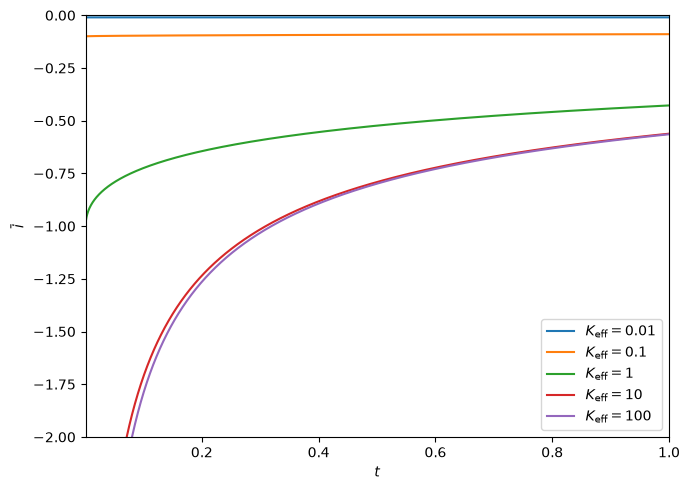

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))

for kinetic_parameter_i, time_i, current_i in zip(
    kinetic_parameters,
    times,
    dimensionless_currents
):
    ax.plot(
        time_i,
        current_i,
        label=fr"$K_{{\mathrm{{eff}}}}={kinetic_parameter_i:g}$"
    )

ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$\bar i$")
ax.set_xlim([0.001, 1])
ax.set_ylim([-2, 0])
ax.legend()

plt.tight_layout()
plt.show()

## Variação da concentração para $K_{eff}=100$

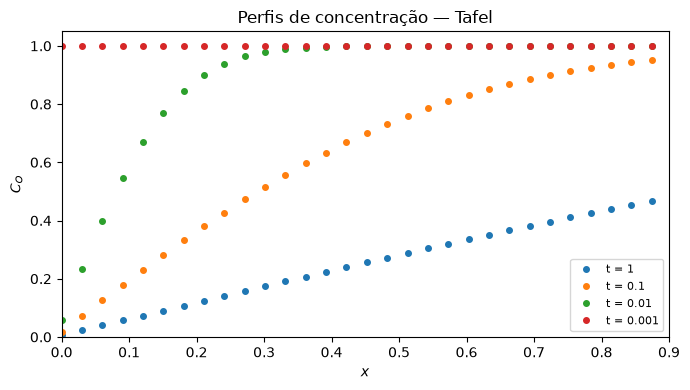

In [9]:
x_plot = np.linspace(0, 6, 200)
times  = [1, 0.1, 0.01, 0.001] # concentrações serão plotadas nestes tempos
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

fig, ax = plt.subplots(figsize=(7, 4))

for t_i in times:
    ax.plot(
        x_plot,
        solution["Concentração de O"](t_i, x_plot), # solution armazena apenas a última solução - keff=100
        ".",
        markersize=8,
        label=f"t = {t_i}", 
    )

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$C_O$")
ax.set_xlim([0, 0.9])
ax.set_ylim([0, 1.05])
ax.set_title("Perfis de concentração — Tafel")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()